
# YOLOv8 Training Performance Analysis

## Key Performance Indicators (KPIs) and Parameters in YOLOv8 Training

### Training Metrics:
- **epoch**: The current training iteration.
- **time**: The elapsed time for the epoch to complete.
- **train/box_loss**: Bounding box regression loss.
- **train/cls_loss**: Classification loss.
- **train/dfl_loss**: Distribution Focal Loss (DFL) for refining predictions.

### Validation Metrics:
- **metrics/precision(B)**: Correct detections / (true positives + false positives).
- **metrics/recall(B)**: True positives / (true positives + false negatives).
- **metrics/mAP50(B)**: Mean Average Precision at 50% IoU.
- **metrics/mAP50-95(B)**: Mean Average Precision across IoU thresholds.

### Validation Losses:
- **val/box_loss**: Bounding box loss on validation data.
- **val/cls_loss**: Classification loss on validation data.
- **val/dfl_loss**: DFL loss during validation.

### Learning Rate:
- **lr/pg0, lr/pg1, lr/pg2**: Learning rates for different model parts.



===== Training Performance Analysis =====

Available columns: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']
train/box_loss: 2.3488 --> ❌ Needs Improvement
train/cls_loss: 2.3736 --> ❌ Needs Improvement
train/dfl_loss: 1.9632 --> ❌ Needs Improvement
metrics/precision(B): 0.2267 --> ❌ Too Low
metrics/recall(B): 0.1464 --> ❌ Too Low
metrics/mAP50(B): 0.0970 --> ❌ Too Low
metrics/mAP50-95(B): 0.0314 --> ❌ Too Low
val/box_loss: 2.5077 --> ❌ Needs Improvement
val/cls_loss: 2.6429 --> ❌ Needs Improvement
val/dfl_loss: 2.1236 --> ❌ Needs Improvement
lr/pg0: 0.0001 --> ❌ Unstable
lr/pg1: 0.0001 --> ❌ Unstable
lr/pg2: 0.0001 --> ❌ Unstable


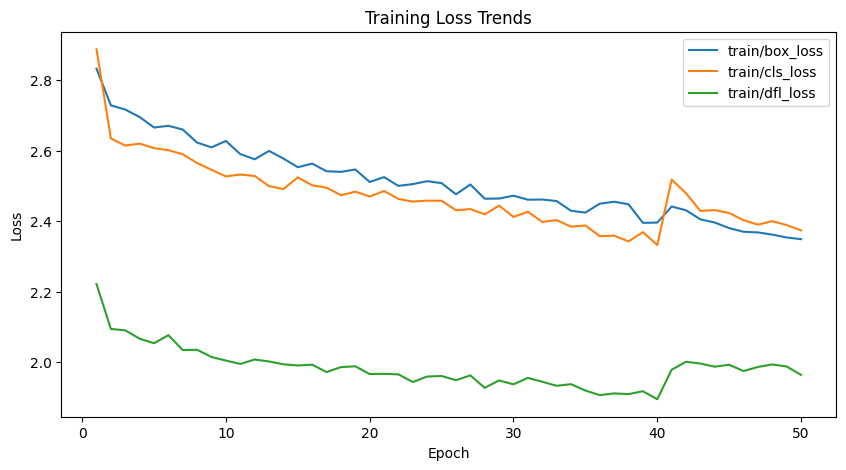

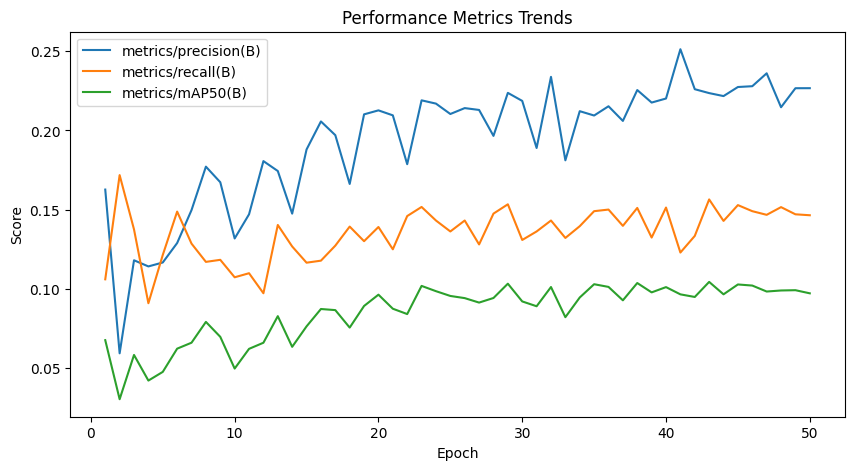

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Define ideal vs. non-ideal thresholds for each metric
ideal_metrics = {
    "train/box_loss": ("low", 1.0),
    "train/cls_loss": ("low", 1.0),
    "train/dfl_loss": ("low", 1.0),
    "metrics/precision(B)": ("high", 0.8),
    "metrics/recall(B)": ("high", 0.8),
    "metrics/mAP50(B)": ("high", 0.7),
    "metrics/mAP50-95(B)": ("high", 0.5),
    "val/box_loss": ("low", 1.0),
    "val/cls_loss": ("low", 1.0),
    "val/dfl_loss": ("low", 1.0),
    "lr/pg0": ("stable", (0.001, 0.01)),
    "lr/pg1": ("stable", (0.001, 0.01)),
    "lr/pg2": ("stable", (0.001, 0.01)),
}

def analyze_training_results(csv_path):
    """Analyzes YOLOv8 training results and compares them with ideal thresholds."""
    df = pd.read_csv(csv_path)
    
    # Fix column name formatting
    df.columns = df.columns.str.strip()  # Removes leading/trailing spaces from column names
    
    print("\n===== Training Performance Analysis =====\n")
    print("Available columns:", df.columns.tolist())
    
    for metric, (trend, threshold) in ideal_metrics.items():
        if metric in df.columns:
            values = df[metric]
            last_value = values.iloc[-1]
            
            if trend == "low":
                status = "✅ Good" if last_value <= threshold else "❌ Needs Improvement"
            elif trend == "high":
                status = "✅ Good" if last_value >= threshold else "❌ Too Low"
            elif trend == "stable":
                status = "✅ Good" if threshold[0] <= last_value <= threshold[1] else "❌ Unstable"
            else:
                status = "⚠ Unknown"
            
            print(f"{metric}: {last_value:.4f} --> {status}")
    
    # Plot training loss trends
    plt.figure(figsize=(10, 5))
    for metric in ["train/box_loss", "train/cls_loss", "train/dfl_loss"]:
        if metric in df.columns and not df[metric].isnull().all():
            plt.plot(df["epoch"], df[metric], label=metric)
    if plt.gca().has_data():
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss Trends")
        plt.legend()
        plt.show()
    else:
        print("No valid training loss data found for plotting.")
    
    # Plot performance metrics
    plt.figure(figsize=(10, 5))
    for metric in ["metrics/precision(B)", "metrics/recall(B)", "metrics/mAP50(B)"]:
        if metric in df.columns and not df[metric].isnull().all():
            plt.plot(df["epoch"], df[metric], label=metric)
    if plt.gca().has_data():
        plt.xlabel("Epoch")
        plt.ylabel("Score")
        plt.title("Performance Metrics Trends")
        plt.legend()
        plt.show()
    else:
        print("No valid performance metric data found for plotting.")
    
# Example usage:
analyze_training_results("runs/detect/train6/results.csv")
